Based on: https://mixtape.scunning.com/09-difference_in_differences

In [1]:
import numpy as np 
import pandas as pd 
import statsmodels.api as sm 
import statsmodels.formula.api as smf 

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from tabulate import tabulate
import textwrap
%matplotlib inline

Context:
* In early 20th century, abortion was illegal in every state
* In 1973, a right to legal abortion was established by US law
* Several states repealed abortion bans by 1970, prior to Roe v. Wade. These include: Alaska, California, Hawaii, New York, and Washington

Context: Gruber, Levine, and Staiger (1999) looked at the characteristics of the "marginal child aborted." They found the counterfactual child aborted would have been:
* More likely to grow up in a single parent household
* More likely to live in poverty
* More likely to receive welfare

$\implies%$ The legalization of abortion altered the characteristics of birth cohorts. 

> "In particular, children's outcomes may have improved on average, because they were more likely to be born into a household in which they were wanted." (Ananats, Gruber, Levine and Staiger, 2009)

There is a (controversial) literature that examines these positive "selection effect" on cohorts born after abortion legalization.

* For example, Donohue and Levitt (2001): abortion legalization led to a drop in crime rates

This paper (Cunningham and Cornwell, 2013) examines how abortion legalization might have impacted long-term gonorrhea incidence
* Idea: counterfactual aborted child is more likley to grow up in a single parent household, and in poverty. This correlates with earlier, riskier sexual activity. By having a legal abortion regime, that child is more likely to be aborted, and overall gonorrhea rates will be lower than in the counterfactual

Methodology:
* A 15-year-old in 1986. She was born in 1971. If in a repeal state, that 15-year-old had access to abortion. If not, they did not, and were more likely to give birth after an unwanted pregnancy.
* Authors observe lower incidence among 15– to 19-year-olds in the repeal states during the 1986–1992 period relative to their Roe state counterparts

In [2]:
url = 'https://github.com/scunning1975/mixtape/raw/master/abortion.dta'
df = pd.read_stata(url)

# drop rows where index is missing
drop_bool = df['id'].isna()
drop_idx = df.loc[drop_bool].index
df = df.drop(index=drop_idx)

# keep only observations where lnr is notna
abortion = df.loc[df['lnr'].notna()].copy()

abortion_bf15 = abortion.loc[abortion['bf15'] == 1].copy()

Estimate:

\begin{equation}
\log (\text{GON})_{st} 
= \beta_1 \cdot \text{Repeal}_s
+ \beta_2 \cdot DT_t + \beta_{3t} \cdot \text{Repeal}_s 
+ X_{st} \xi + \alpha_{1s} DS_s + \gamma_{2s} D_{s} \cdot t + \epsilon_{st}
\end{equation}
where:
* GON is the number of new gonorrhea cases for 15–19-year-olds (per 100,000 of the population) in state $s$ and year $t$; 
* $\text{Repeal}_s = 1$ if state $s$ legalized abortion prior to Roe; 
* $DT_t$ is a year indicator; 
* $DS_s$ is a state indicator;
* $t$ is a time trend (not included in first regression)
* $X$ st is a vector of covariates; 
* $\epsilon_{st}$ is an error term. The
parameters of interest are the β3t , which capture the effects of the early
repeal of abortion bans on gonorrhea incidence in the treated birth cohort
15–19 years later

In [3]:
formula = (
    "lnr ~ C(repeal)*C(year) + C(fip)"
    " + acc + ir + pi + alcohol + crack + poverty + income + ur"
)

wls_mod = smf.wls(formula, data=abortion_bf15, weights=abortion_bf15['totpop'])
wls_res = wls_mod.fit(
    cov_type='cluster', 
    cov_kwds={'groups': abortion_bf15['fip']},
    method='pinv'
)

wls_res.summary(slim=True)

/opt/anaconda3/envs/venv_econ726/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 89, but rank is 27
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/venv_econ726/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                    lnr   R-squared:                       0.857
Model:                            WLS   Adj. R-squared:                  0.837
No. Observations:                 737   F-statistic:                     1898.
Covariance Type:              cluster   Prob (F-statistic):           1.66e-66
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              7.4753      1.176      6.356      0.000       5.170       9.781
C(repeal)[T.1.0]                      -1.3596      0.412     -3.296      0.001      -2.168      -0.551
C(year)[T.1986.0]                     -0.0208      0.058     -0.361      0.718      -0.134       0.092
C(year)[T.1987.0]                     -0.2865      0.111     -2.579      0.010      -0.504      -0.069
C(year)[T.1988.0]                     -0.3495      0.131     -2.667      0.008      -0.606      -0.093
C(year)[T.1989.0]                     -0.4072      0.173     -2.349      0.019      -0.747      -0.067
C(year)[T.1990.0]                     -0.4864      0.217     -2.244      0.025      -0.911      -0.062
C(year)[T.1991.0]                     -0.5353      0.223     -2.398      0.016      -0.973      -0.098
C(year)[T.1992.0]                     -0.7866      0.269     -2.927      0.003      -1.313      -0.260
C(year)[T.1993.0]                     -0.9767      0.287     -3.403      0.001      -1.539      -0.414
C(year)[T.1994.0]                     -1.0644      0.323     -3.297      0.001      -1.697      -0.432
C(year)[T.1995.0]                     -1.3562      0.375     -3.612      0.000      -2.092      -0.620
C(year)[T.1996.0]                     -1.5201      0.415     -3.667      0.000      -2.333      -0.707
C(year)[T.1997.0]                     -1.5718      0.468     -3.359      0.001      -2.489      -0.655
C(year)[T.1998.0]                     -1.5451      0.536     -2.884      0.004      -2.595      -0.495
C(year)[T.1999.0]                     -1.5874      0.579     -2.743      0.006      -2.722      -0.453
C(year)[T.2000.0]                     -1.6726      0.658     -2.543      0.011      -2.962      -0.383
C(fip)[T.2.0]                         -0.4761      0.267     -1.784      0.074      -0.999       0.047
C(fip)[T.4.0]                         -0.9589      0.524     -1.829      0.067      -1.986       0.068
C(fip)[T.5.0]                          0.0860      0.065      1.319      0.187      -0.042       0.214
C(fip)[T.6.0]                          0.0982      0.192      0.512      0.608      -0.277       0.474
C(fip)[T.8.0]                         -0.8246      0.418     -1.971      0.049      -1.645      -0.005
C(fip)[T.9.0]                         -1.6809      0.736     -2.285      0.022      -3.122      -0.239
C(fip)[T.10.0]                        -0.7458      0.484     -1.540      0.123      -1.695       0.203
C(fip)[T.11.0]                        -2.1124      1.246     -1.695      0.090      -4.555       0.331
C(fip)[T.12.0]                        -1.0947      0.514     -2.132      0.033      -2.101      -0.088
C(fip)[T.13.0]                        -0.7216      0.246     -2.930      0.003      -1.204      -0.239
C(fip)[T.15.0]                        -0.3897      0.104     -3.740      0.000      -0.594      -0.185
C(fip)[T.16.0]                        -1.7937      0.199     -8.994      0.000      -2.185      -1.403
C(fip)[T.17.0]                        -0.7228      0.459     -1.575      0.115      -1.622       0.177
C(fip)[T.18.0]                        -0.1432      0.187     -0.765      0.444 

In [4]:
# did_coef = 
wls_res.summary()

"C(repeal)[T.1.0]:C(year)[T.1986.0]':'C(repeal)[T.1.0]:C(year)[T.2000.0]"
# keep the exogenous variables that contain the colon ":"
# the colon indicates interaction terms in statsmodels variable lists
did_vars = [var for var in wls_mod.exog_names if ':' in var]
did_vars

['C(repeal)[T.1.0]:C(year)[T.1986.0]',
 'C(repeal)[T.1.0]:C(year)[T.1987.0]',
 'C(repeal)[T.1.0]:C(year)[T.1988.0]',
 'C(repeal)[T.1.0]:C(year)[T.1989.0]',
 'C(repeal)[T.1.0]:C(year)[T.1990.0]',
 'C(repeal)[T.1.0]:C(year)[T.1991.0]',
 'C(repeal)[T.1.0]:C(year)[T.1992.0]',
 'C(repeal)[T.1.0]:C(year)[T.1993.0]',
 'C(repeal)[T.1.0]:C(year)[T.1994.0]',
 'C(repeal)[T.1.0]:C(year)[T.1995.0]',
 'C(repeal)[T.1.0]:C(year)[T.1996.0]',
 'C(repeal)[T.1.0]:C(year)[T.1997.0]',
 'C(repeal)[T.1.0]:C(year)[T.1998.0]',
 'C(repeal)[T.1.0]:C(year)[T.1999.0]',
 'C(repeal)[T.1.0]:C(year)[T.2000.0]']

In [5]:
# Function to generate significance stars
def get_significance_stars(pval):
    if pval < 0.001:
        return '****'
    elif pval < 0.01:
        return '***'
    elif pval < 0.05:
        return '**'
    elif pval < 0.1:
        return '*'
    else:
        return ''

# combining the above into a function
def get_result_array(res, keep_vars, name=None):
    coef_series = (
        res.params[keep_vars].round(3).astype(str)           # format the estimated parameters as rounded strings
        +                                                        # use addition to add stars (if any)
        res.pvalues.apply(get_significance_stars)[keep_vars] # generate significance stars
    )
    coef_series.name = 'coef'  # naming series will be helpful when this is a dataframe
    tvalue_series = '(' + res.bse[keep_vars].round(3).astype(str) + ')' # add parentheses around formatted t-values
    tvalue_series.name = 'se'
    obs_series = pd.Series([f'{res.nobs:.0f}'], index=['_nobs'], name='obs')

    ols_res_series = pd.concat([coef_series, tvalue_series, obs_series]).sort_index(ascending=False)
    if name is not None:
        ols_res_series.name = name

    # reorder index
    index_order = keep_vars + ['_nobs']
    ols_res_series = ols_res_series.loc[index_order]
    
    return ols_res_series

get_result_array(wls_res, keep_vars=did_vars)

C(repeal)[T.1.0]:C(year)[T.1986.0]    -0.259****
C(repeal)[T.1.0]:C(year)[T.1986.0]       (0.063)
C(repeal)[T.1.0]:C(year)[T.1987.0]      -0.342**
C(repeal)[T.1.0]:C(year)[T.1987.0]       (0.168)
C(repeal)[T.1.0]:C(year)[T.1988.0]       (0.203)
C(repeal)[T.1.0]:C(year)[T.1988.0]     -0.611***
C(repeal)[T.1.0]:C(year)[T.1989.0]    -0.785****
C(repeal)[T.1.0]:C(year)[T.1989.0]       (0.237)
C(repeal)[T.1.0]:C(year)[T.1990.0]    -0.632****
C(repeal)[T.1.0]:C(year)[T.1990.0]       (0.176)
C(repeal)[T.1.0]:C(year)[T.1991.0]       (0.139)
C(repeal)[T.1.0]:C(year)[T.1991.0]    -0.553****
C(repeal)[T.1.0]:C(year)[T.1992.0]     -0.442***
C(repeal)[T.1.0]:C(year)[T.1992.0]        (0.16)
C(repeal)[T.1.0]:C(year)[T.1993.0]       (0.181)
C(repeal)[T.1.0]:C(year)[T.1993.0]       -0.306*
C(repeal)[T.1.0]:C(year)[T.1994.0]        -0.118
C(repeal)[T.1.0]:C(year)[T.1994.0]       (0.207)
C(repeal)[T.1.0]:C(year)[T.1995.0]       (0.223)
C(repeal)[T.1.0]:C(year)[T.1995.0]         0.021
C(repeal)[T.1.0]:C(y

In [6]:
conf_int = wls_res.conf_int()
conf_int = conf_int.loc[did_vars]
conf_int.columns = ['lb', 'ub']

mean_arr = wls_res.params[did_vars]
mean_arr.name = 'mean'

plot_df = pd.concat([mean_arr, conf_int], axis=1)

# extract year from list of interaction terms
plot_df['year'] = plot_df.index.str.extract(r'C\(year\)\[T\.(\d{4})\.0\]', expand=False)
# convert string version of year to an int
plot_df['year'] = plot_df['year'].astype(int)


Text(0.5, 1.0, 'Estimated effect of abortion legalization on gonorrhea')

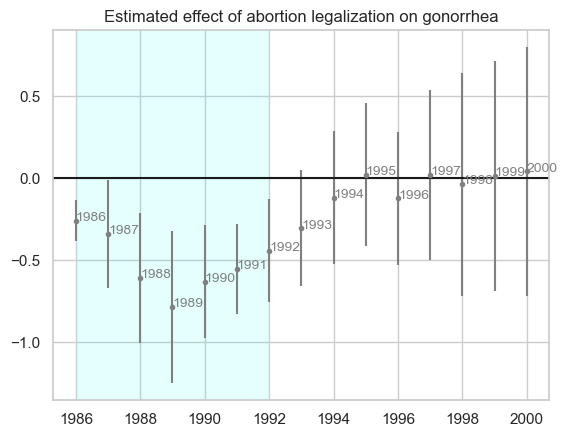

In [7]:
fig, ax = plt.subplots()

error_bars = [
    np.abs(plot_df['mean'] - plot_df['lb']).values, # lower error
    np.abs(plot_df['mean'] - plot_df['ub']).values
]

ax.errorbar(
    x=plot_df['year'], 
    y=plot_df['mean'],
    yerr=error_bars,
    color='gray', marker='.', linestyle='none'
)

ax.axhline(0, color='k')

ax.axvspan(
    xmin=plot_df['year'].min(),
    xmax=1992,
    facecolor="cyan", alpha=.1
)

for i, txt in enumerate(plot_df['year'].values):

    x_val = plot_df.iloc[i]['year']
    y_val = plot_df.iloc[i]['mean']

    print_val = str(x_val.astype(int))

    ax.annotate(text=print_val, xy=(x_val, y_val), fontsize=10, color='gray')

ax.set_title("Estimated effect of abortion legalization on gonorrhea")
